# <u>Monday Coffee: India Expansion Analysis</u>

## <u>Project Overview and Data Loading</u>

**Monday Coffee** is a coffee business looking to expand by opening 3 new in-person stores in India. The business has collected data from its existing online customer base across major Indian cities.

The objective of this analysis is to identify the 3 cities with the strongest potential for expansion by analysing market size, existing customer demand and consumer habits, sales performance and the estimated rental costs of each city. The findings will be used to deliver data-driven recommendations on where Monday Coffee should open its first 3 in-person storefronts. **The dataset does not mention a currency so I will not denote one in the analysis, but it is to be assumed that the revenue is in `INR (Indian Rupee)`

The SQL queries that are used to conduct the analysis are included in the project hierarchy.

In [1]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns
from IPython.display import display
pd.set_option('display.max_rows', None)


In [2]:
# Create and populate the tables
city = pd.read_csv('Monday Coffee Data/city.csv')
customers = pd.read_csv('Monday Coffee Data/customers.csv')
products = pd.read_csv('Monday Coffee Data/products.csv')
sales = pd.read_csv('Monday Coffee Data/sales.csv')

In [3]:
city.head()

,city_id,city_name,population,estimated_rent,city_rank
0,1,Bangalore,12300000,29700,1
1,2,Chennai,11100000,17100,6
2,3,Pune,7500000,15300,9
3,4,Jaipur,4000000,10800,8
4,5,Delhi,31000000,22500,3


In [4]:
customers.head()

,customer_id,customer_name,city_id
0,1,Aarav Agarwal,1
1,2,Aarav Pandey,1
2,3,Aditi Gupta,1
3,4,Aditi Joshi,1
4,5,Aditi Reddy,1


In [5]:
products.head()

,product_id,product_name,price
0,1,Ground Espresso Coffee (250g),350
1,2,Cold Brew Coffee Pack (6 Bottles),900
2,3,Instant Coffee Powder (100g),250
3,4,Coffee Beans (500g),600
4,5,Coffee Drip Bags (10 Bags),450


In [6]:
sales['sale_date'] = pd.to_datetime(sales['sale_date'])
sales.head()
print(sales['sale_date'].min())
print(sales['sale_date'].max())

2023-01-01 00:00:00
2024-10-01 00:00:00


## <u> Dataset Overview </u>

The analysis uses four datasets containing information about Monday Coffee's **online coffee business**, including the cities in which it operates, its customers, a catalogue of its products and sales transactions. The data covers the period from `1st January 2023` to `1st October 2024` and contains information that can be used to assess existing customer demand and the viability of different cities in India for potential expansions through in-person storefronts. 

The datasets are:

**city** – A table containing the names of cities in India, the population of each city and the estimated rent for a storefront in each city. `city_id` is the **primary key** for this table, uniquely identifying each city. The population data is used to estimate the number of potential coffee drinkers in each city.

**customers** – Contains the name of each customer that has a purchase history with Monday Coffee's online business. `customer_id` is the **primary key**, uniquely identifying each customer. `city_id` is the **foreign key**, linking each customer to their city in the city table.

**products** – A table storing the name and retail price of each product. `product_id` is the **primary key**. The table contains both coffee product and non-coffee merchandise. 

**sales** – Contains information of individual transactions, including the sale date, customer, product id, transaction value and customer rating. `sale_id` is the **primary key**, uniquely identifying each sale. `customer_id` and `product_id` are **foreign keys**, linking each transaction to the relevant customer and product. 

These relationships form the structure used throughout the SQL analysis. The `customers` table ties each user to their relevant city, while the `sales` table links each purchase to both a customer and product. This allows the existing sales activity to be analysed at a city level and combined with population and rental information to evaluate which cities may have the strongest potential for expansion through opening in-person storefronts. 

## <u>Which Cities Have the Best Market Potential?</u>

### Estimated Coffee Consumers

A key metric when considering expansion is the percent of the population that can be converted to customers in each city, as this can be used as a proxy for demand. This analysis approximates the potential market of each city by estimating that approximately 25% of the population consumes coffee. Comparing these estimates across different cities in India provides an indication of the potential customer base if a storefront were to be established in that city. 

``` sql
SELECT 
	city_name,
	ROUND((population * 0.25)/1000000, 2) as estimated_coffee_consumers_millions,
	city_rank
FROM city
ORDER BY 2 DESC
```

In [7]:
est_coffee_cons_millions = pd.read_csv('SQL Queries/estimated_coffee_consumers_millions.csv')
est_coffee_cons_millions = est_coffee_cons_millions.sort_values(by='estimated_coffee_consumers_millions', ascending=False)

,city_name,estimated_coffee_consumers_millions,city_rank
0,Delhi,7.75,3
1,Mumbai,5.10,2
2,Kolkata,3.73,7
3,Bangalore,3.08,1
4,Chennai,2.78,6
5,Hyderabad,2.50,4
6,Ahmedabad,2.08,5
7,Pune,1.88,9
8,Surat,1.80,10
9,Jaipur,1.00,8


Text(0, 0.5, 'City Name')

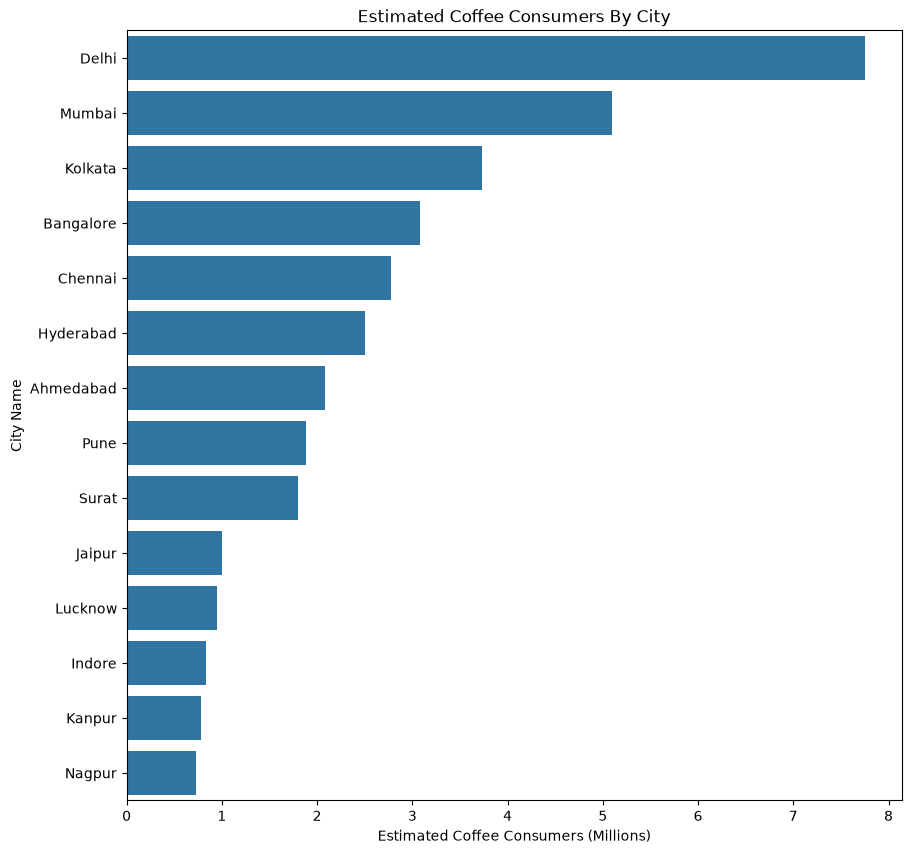

In [8]:
display(est_coffee_cons_millions)
plt.figure(figsize=(10, 10))
sns.barplot(data = est_coffee_cons_millions, x = 'estimated_coffee_consumers_millions', y = 'city_name')
plt.title("Estimated Coffee Consumers By City")
plt.xlabel("Estimated Coffee Consumers (Millions)")
plt.ylabel("City Name")

`Delhi` has the largest estimated coffee-drinking population at `7.75 million` followed by `Mumbai` with `5.10 million` and `Kolkata` with `3.73 million`. `Bangalore` and `Chennai` also have a relatively large potential customer base, with `3.08 million` and `2.78 million` estimated coffee drinkers respectively. 

The results show that larger cities offer a larger potential customer base as a result of their larger populations, though it is important to note that population size alone does not solely indicate whether a city is suitable for expansion. Other factors must be considered such as existing customer demand, sales performance and estimated rental cost, and these factors will be considered alongside market size when considering which cities to expand in. 

## <u>Where Are People Already Buying From Monday Coffee?</u>

Understanding where Monday Coffee already has a customer base can provide an indication of existing demand and brand recognition across the different cities in India. Cities that have a larger pre-existing customer base for the online orders may represent stronger opportunities for expansion, as there is already evidence that customers in these cities are willing to make purchases from the business. Consumer purchasing behaviour will also be examined in these cities to identify which products are more popular in each city. 

### Existing Customers By City

``` sql
SELECT 
	ci.city_name,
	COUNT (DISTINCT c.customer_id) as unique_cx
	
FROM city as ci
LEFT JOIN customers as c
ON c.city_id = ci.city_id
JOIN sales as s
ON s.customer_id = c.customer_id
WHERE
	s.product_id IN (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14)
GROUP BY 1
```

In [9]:
unique_customers_city = pd.read_csv('SQL Queries/unique_customers_each_city.csv')
unique_customers_city = unique_customers_city.sort_values(by='unique_cx', ascending=False)

,city_name,unique_cx
6,Jaipur,69
3,Delhi,68
12,Pune,52
2,Chennai,42
1,Bangalore,39
7,Kanpur,35
8,Kolkata,28
10,Mumbai,27
13,Surat,27
11,Nagpur,24


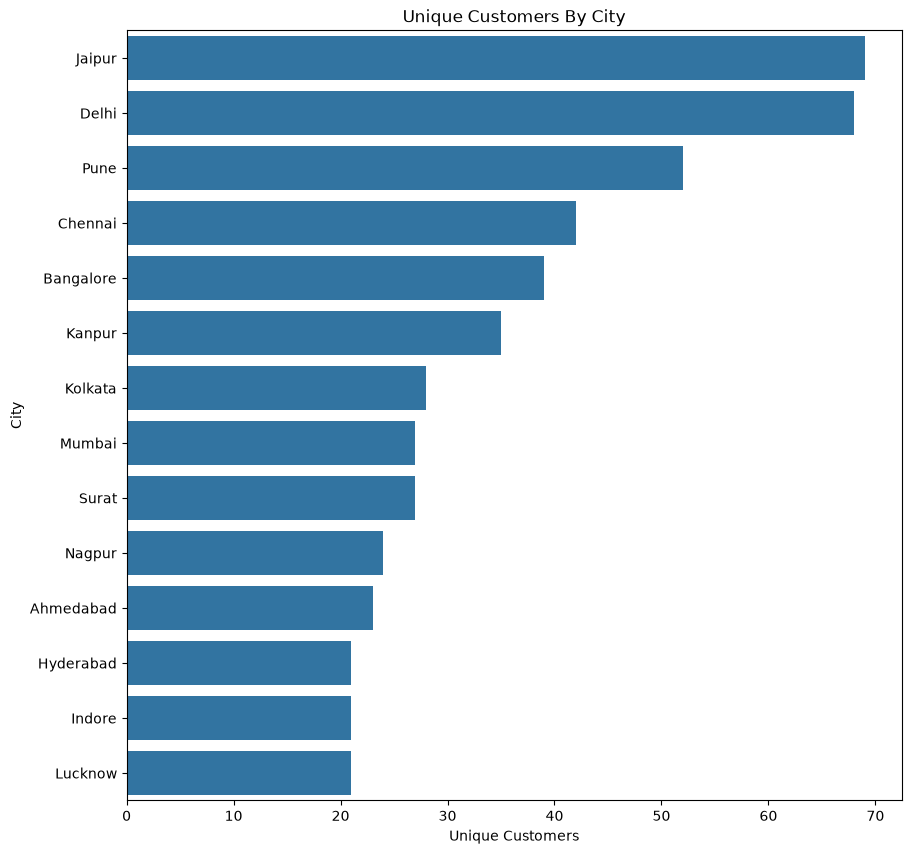

In [10]:
display(unique_customers_city)

plt.figure(figsize=(10, 10))
sns.barplot(data = unique_customers_city, x = 'unique_cx', y = 'city_name')
plt.title("Unique Customers By City")
plt.xlabel("Unique Customers")
plt.ylabel("City")
plt.show()

`Jaipur` has the largest number of unique customers with a count of `69`, closely followed by `Delhi` with a count of `68`. `Pune` has the third-highest customer base with `52` followed by `Chennai` and `Bangalore` with counts of `42` and `39` respectively. 

It's interesting to note that this differs from the previous analysis in which we focussed on the estimated number of coffee drinkers in each city. For example, `Delhi` has the highest number of estimated coffee drinkers at `7.75 million`, but `Jaipur` has the highest number of existing customers even though there are only an estimated number of `1 million` coffee drinkers in the city, which is comparatively small compared to `Delhi`. This suggests that population size alone may not reflect the true level of demand for Monday Coffee, meaning that existing customer activity is an important factor to consider when deciding where to expand to.

### Top 3 Products Each City

The previous analysis identified which cities where Monday Coffee operates have the largest customer bases. To better understand consumer behaviour within these markets the top 3 most popular products within each city were analysed.  

``` sql
WITH product_sales AS
(
    SELECT
        ci.city_name,
        p.product_name,
        COUNT(s.sale_id) AS sales_volume
    FROM sales AS s
    JOIN customers AS c
        ON s.customer_id = c.customer_id
    JOIN city AS ci
        ON c.city_id = ci.city_id
    JOIN products AS p
        ON s.product_id = p.product_id
    GROUP BY
        ci.city_name,
        p.product_name
),

ranked_products AS
(
    SELECT
        city_name,
        product_name,
        sales_volume,
        RANK() OVER (
            PARTITION BY city_name
            ORDER BY sales_volume DESC
        ) AS product_rank
    FROM product_sales
)

SELECT
    city_name,
    product_name,
    sales_volume
FROM ranked_products
WHERE product_rank <= 3
ORDER BY
    city_name,
    product_rank;
```

In [11]:
city_top_3 = pd.read_csv('SQL Queries/top_3_product_by_city.csv')
city_top_3.sort_values(by='sales_volume')

,city_name,product_name,sales_volume
29,Lucknow,Cold Brew Coffee Pack (6 Bottles),23
30,Lucknow,Ground Espresso Coffee (250g),23
28,Lucknow,Coffee Beans (500g),25
16,Indore,Cold Brew Coffee Pack (6 Bottles),26
17,Indore,Ground Espresso Coffee (250g),26
2,Ahmedabad,Instant Coffee Powder (100g),26
14,Hyderabad,Ground Espresso Coffee (250g),27
37,Nagpur,Cold Brew Coffee Pack (6 Bottles),28
27,Lucknow,Instant Coffee Powder (100g),28
13,Hyderabad,Cold Brew Coffee Pack (6 Bottles),28


`Cold Brew Coffee Pack (6 Bottles)`, `Ground Espresso Coffee (250g)`, `Instant Coffee Powder (100g` and `Coffee Beans (500g)` appear consistently amongst the most purchased products across the cities. `Cold Brew Coffee Pack (6 Bottles)` is particularly popular, appearing in the top 3 products in almost every city. \
The relatively similar mix of products within the top 3 most sold for each city suggests that customer preferences are largely similar between the different markets. However, the substantially higher sales volume in `Pune`, `Bangalore`, `Chennai`, `Delhi` and `Jaipur` provides evidence that customer activity is stronger in these markets, which can be considered alongside customer and revenue analysis when considering where to expand to. 

## <u>Which Cities Are Generating the Most Revenue?</u>

### Revenue by City

Revenue generated by each city provides further evidence of where demand for Monday Coffee is strongest. The previous analysis showed the size of the potential market (percent of estimated coffee drinkers) and the number of existing customers, revenue shows the financial contribution generated by customers in each city. Comparing the sales revenue across cities in India can therefore provide help identify locations where customer activity is translating into stronger sales performance. 

The following analysis will focus on revenue generated across different cities in `quarter 4 of 2023`. 

``` sql 
SELECT 
	ci.city_name,
	SUM(s.total) as total_Q4_2023
	
FROM sales as s
JOIN customers as c
ON s.customer_id = c.customer_id
JOIN city as ci
ON c.city_id = ci.city_id

WHERE
	EXTRACT (QUARTER FROM s.sale_date) = 4
AND	
	EXTRACT (YEAR FROM s.sale_date) = 2023

GROUP BY 1
ORDER BY 2 DESC
```

In [12]:
revenue_by_city_q4 = pd.read_csv('SQL Queries/Revenue by City Q4.csv')
revenue_by_city_q4 = revenue_by_city_q4.sort_values(by='total_q4_2023', ascending=False)

,city_name,total_q4_2023
0,Pune,434330
1,Chennai,302500
2,Bangalore,270780
3,Jaipur,248580
4,Delhi,238490
5,Kanpur,71890
6,Mumbai,71340
7,Surat,52560
8,Kolkata,51180
9,Nagpur,45810


<Figure size 640x480 with 0 Axes>

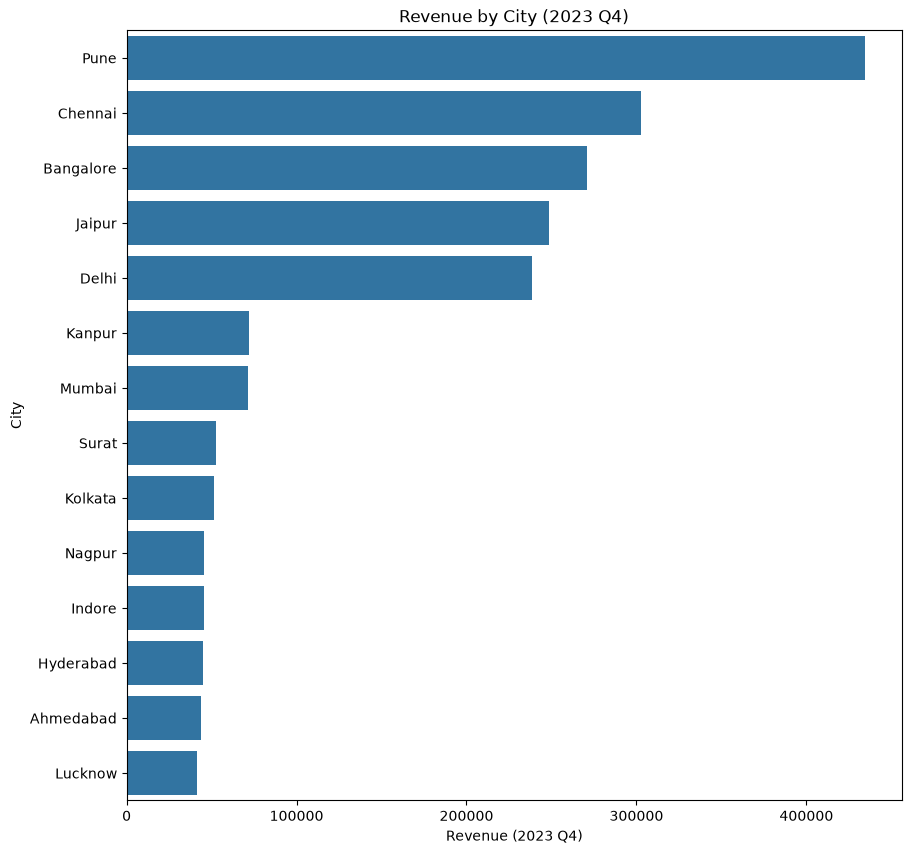

In [13]:
display(revenue_by_city_q4)
plt.clf()
plt.figure(figsize=(10, 10))
sns.barplot(data = revenue_by_city_q4, x = 'total_q4_2023', y = 'city_name')
plt.title("Revenue by City (2023 Q4)")
plt.xlabel("Revenue (2023 Q4)")
plt.ylabel("City")
plt.show()

`Pune` generated the highest revenue in the final quarter of 2023 at `434330` followed by `Chennai` at `302500` and `Bangalore` at `270780`. `Jaipur` and `Delhi` follow closely at `248580` and `238490` respectively. 

The results become more interesting when compared against the estimated coffee consumers of each city. `Delhi` had the highest estimated number of coffee consumers at `7.75 million` but generated a revenue of `238490`. This is substantially lower than `Pune`, which generated a revenue of `434330`, almost twice as much even though it has an estimated number of `1.88 million` coffee drinkers! Similarly, `Chennai` generated substantially more revenue than `Mumbai` despite having almost half of the estimated coffee-consuming population.

This suggests that a larger potential market does not necessarily translate into an increased market penetration. Cities such as `Pune`, `Chennai`, `Bangalore` and `Jaipur` are converting a relatively small coffee-drinking population into stronger sales figures, making their demand particularly relevant when considering where to expand Monday Coffee. 

### Market Penetration

In [14]:
est_coffee_cons_millions
market_penetration = pd.DataFrame()
market_penetration['city'] = est_coffee_cons_millions['city_name'].copy()
market_penetration['est_coffee_cons'] = est_coffee_cons_millions['estimated_coffee_consumers_millions']*1000000
#we used sort values earlier, so we set city_name as the index and use map to return the unique_cx of each city
market_penetration['unique_cx'] = market_penetration['city'].map(unique_customers_city.set_index('city_name')['unique_cx'])
market_penetration['penetration_pct'] = (market_penetration['unique_cx'] / market_penetration['est_coffee_cons']*100)
market_penetration = market_penetration.sort_values(by='penetration_pct', ascending=False)

,city,est_coffee_cons,unique_cx,penetration_pct
9,Jaipur,1000000.0,69,0.006900
12,Kanpur,780000.0,35,0.004487
13,Nagpur,730000.0,24,0.003288
7,Pune,1880000.0,52,0.002766
11,Indore,830000.0,21,0.002530
10,Lucknow,950000.0,21,0.002211
4,Chennai,2780000.0,42,0.001511
8,Surat,1800000.0,27,0.001500
3,Bangalore,3080000.0,39,0.001266
6,Ahmedabad,2080000.0,23,0.001106


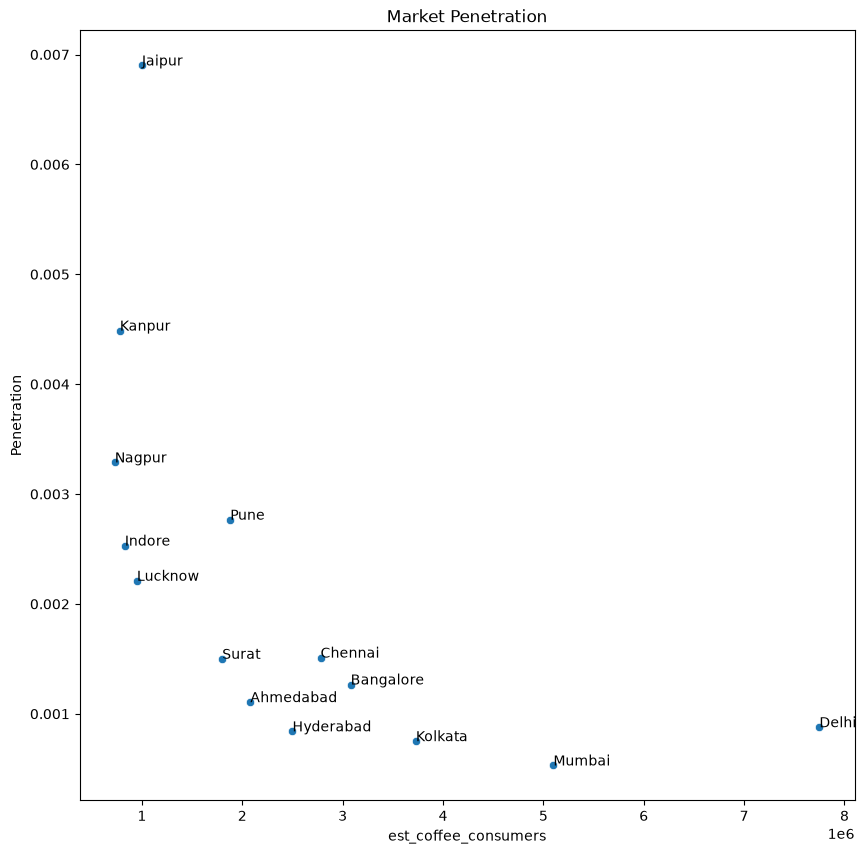

In [15]:
display(market_penetration)
plt.figure(figsize=(10, 10))
sns.scatterplot(data = market_penetration, x = 'est_coffee_cons', y = 'penetration_pct')

for _, row in market_penetration.iterrows():
    plt.text(
        row['est_coffee_cons'],
        row['penetration_pct'],
        row['city'])

plt.title("Market Penetration")
plt.xlabel("est_coffee_consumers")
plt.ylabel("Penetration")
plt.show()

The estimated market penetration varies considerably between different cities. `Jaipur` has the largest penetration at `~0.007%`, followed by `Kanpur` at `~0.004%` and `Nagpur` at `~0.003%`. In contrast, `Mumbai`, `Kolkata` and `Hyderabad` have some of the lowest market penetration despite having some of the largest numbers of estimated coffee-consumers. 

`Jaipur` is particularly notable as it has an estimated `1 million` coffee drinkers and an existing customer base of `69`, making it the city with the highest level of penetration in the dataset. `Delhi` is an interesting contrast to this, having a penetration of only `~0.0009%` even though it has the highest number of estimated coffee-consumers in the dataset (`7,750,000`). 

`Pune` stands out as another particularly strong market. It has a relatively small coffee-consuming population at `1,880,000` and a customer base of `52`, resulting in a market penetration of `0.00278%`. Combined with the fact that `Pune` had the strongest earnings in the final quarter of 2023 at `434,330`, this provides multiple indicators of strong existing demand for Monday Coffee despite the city having a smaller potential market size. 

Overall, these results suggest that the size of a potential market does not necessarily correspond to Monday Coffee’s existing reach or sales performance within that market. Smaller cities such as `Jaipur` and `Pune` have achieved relatively strong customer reach within their estimated markets, while larger cities may provide greater potential for future growth due to their substantially larger populations.

### Average Revenue Per Customer by City

While the total revenue of each city gives a metric of the overall sales performance, it does not account for the differences in population size of the existing customer base. I will therefore calculate the average revenue generated per customer for each city which will approximate how much income Monday Coffee generates from each unique customer in each city. 

This metric can help identify cities where customers are generating a relatively higher revenue, which may indicate stronger purchasing power or a higher brand-loyalty. These results will be considered alongside total revenue, customer numbers and estimated market penetration when considering potential locations to expand to. 

``` sql
SELECT
	ci.city_name,
	SUM(s.total) as total_revenue,
	COUNT (DISTINCT s.customer_id) as total_customers,
	ROUND(
		SUM(s.total)::numeric/COUNT(DISTINCT s.customer_id), 2) as average_revenue
FROM sales as s
JOIN customers as c
ON s.customer_id = c.customer_id
JOIN city as ci
ON c.city_id = ci.city_id
GROUP BY 1
ORDER BY 4 DESC
```

In [16]:
avg_revenue_per_customer_city = pd.read_csv('SQL Queries/avg_revenue_per_customer_city.csv')
avg_revenue_per_customer_city = avg_revenue_per_customer_city.sort_values(by='average_revenue', ascending=False)

,city_name,total_revenue,total_customers,average_revenue
0,Pune,1258290,52,24197.88
1,Chennai,944120,42,22479.05
2,Bangalore,860110,39,22054.10
3,Jaipur,803450,69,11644.20
4,Delhi,750420,68,11035.59
5,Mumbai,235000,27,8703.70
6,Indore,138590,21,6599.52
7,Surat,176540,27,6538.52
8,Hyderabad,131520,21,6262.86
9,Kolkata,171460,28,6123.57


Text(0, 0.5, 'City')

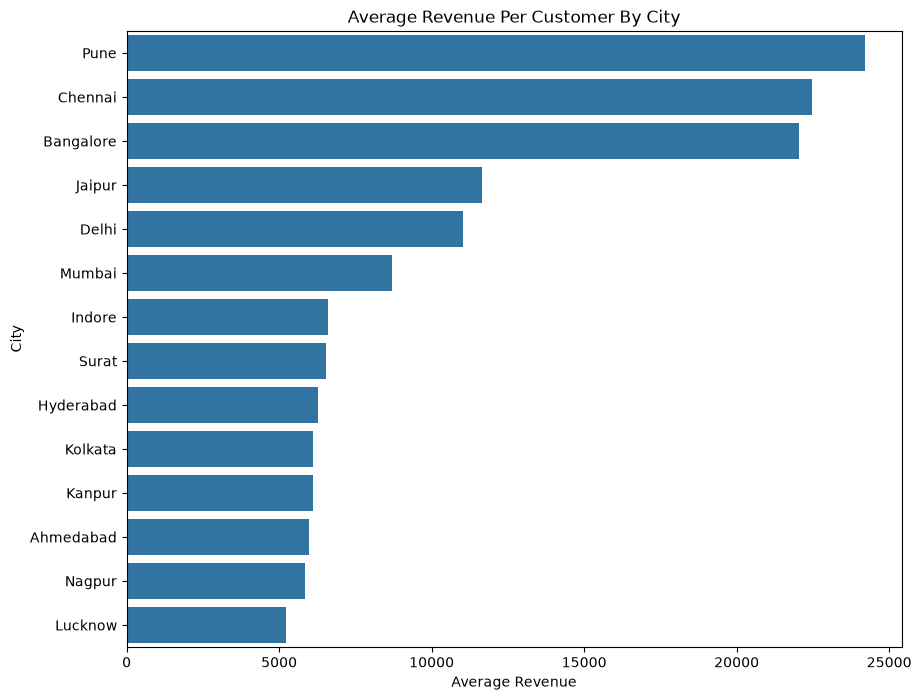

In [17]:
display(avg_revenue_per_customer_city)

plt.figure(figsize=(10, 8))
sns.barplot(data = avg_revenue_per_customer_city, x = 'average_revenue', y = 'city_name')
plt.title("Average Revenue Per Customer By City")
plt.xlabel("Average Revenue")
plt.ylabel("City")

`Pune` generates the most revenue per customer with an average of `24197.88`, followed by `Chennai` at `22479.05` and `Bangalore` at `22054.10`. This is consistent with the strong overall sales performance of these cities, suggesting that the existing customer base in these cities is generating a relatively high level of revenue. 

`Jaipur` and `Delhi` have the next highest average revenues but there is a significant drop from the prior cities, at `11644.20` and `11035.59` respectively. It's worth noting that these cities have an existing customer base of `69` and `68`, even though they generate substantially less revenue. This suggests that having a higher number of existing customers does not necessarily translate into an increased revenue per customer. 

`Pune` stands out in particular as even though it has a relatively small coffee-consuming population, it has a comparatively high market penetration, the highest total revenue and also the highest average revenue per customer. This provides further evidence that `Pune` has a strong existing customer base and coupled with its relatively high revenue it makes it a compelling city for expansion.

### Monthly Sales Growth by City

While total revenue and average customer spend provides a glimpse of sales performance, analysing the sales growth on a month to month basis provide insight into how sales performance has changed over time. There are too many cities in the dataset to visualise the trends of them all, so this analysis will limit the number of cities to the 5 that bring in the most revenue, allowing their month to month sales performance to be compared. 

Examining the percent increase and decrease in monthly revenue can help identify whether these top performing cities are showing continuous growth, period of decline or fluctuations in their sales performance over time. This provides an additional indicator of strength and consistency for the market of each city. 

#### Monthly Growth

``` sql
WITH
mothly_sales
AS
(SELECT 
	ci.city_name,
	EXTRACT(MONTH FROM sale_date) as month,
	EXTRACT (YEAR FROM sale_date) as year,
	SUM(s.total) as total_sale
FROM sales as s
JOIN customers as c
ON c.customer_id = s.customer_id
JOIN city as ci
ON ci.city_id = c.city_id
GROUP BY 1, 2, 3
ORDER BY 1, 3, 2 ASC	
),
growth_ratio
AS
	(SELECT
		city_name,
		month,
		year,
		total_sale as cr_month_sale,
		LAG(total_sale, 1) OVER(PARTITION BY city_name ORDER BY year, month) as last_month_sale
	FROM mothly_sales
	)

SELECT
	city_name,
	month,
	year,
	cr_month_sale,
	last_month_sale,
	ROUND(
	(cr_month_sale - last_month_sale)::numeric/last_month_sale::numeric*100,
		2) as percent_increase
FROM growth_ratio
WHERE last_month_sale IS NOT NULL
```

In [18]:
monthly_growth_by_city = pd.read_csv('SQL Queries/Monthly Growth by City.csv')
monthly_growth_by_city['date'] = pd.to_datetime(monthly_growth_by_city[['year', 'month']].assign(day=1))
monthly_growth_by_city.head(5)

,city_name,month,year,cr_month_sale,last_month_sale,percent_increase,date
0,Ahmedabad,2,2023,4100,3750,9.33,2023-02-01
1,Ahmedabad,3,2023,3050,4100,-25.61,2023-03-01
2,Ahmedabad,4,2023,4040,3050,32.46,2023-04-01
3,Ahmedabad,5,2023,2550,4040,-36.88,2023-05-01
4,Ahmedabad,6,2023,2900,2550,13.73,2023-06-01


In [19]:
top_cities = ['Pune', 'Chennai', 'Bangalore', 'Jaipur', 'Delhi']
monthly_growth_top_cities = monthly_growth_by_city[monthly_growth_by_city['city_name'].isin(top_cities)]
monthly_growth_top_cities['city_name'].unique()

<StringArray>
['Bangalore', 'Chennai', 'Delhi', 'Jaipur', 'Pune']
Length: 5, dtype: str

The month of `October 2024` is the end of the dataset and contains very few values compared to the prior months. It's suspected that this month contains incomplete data, so I will filter it from the dataset when creating the graph of sales figures over time.

<Figure size 640x480 with 0 Axes>

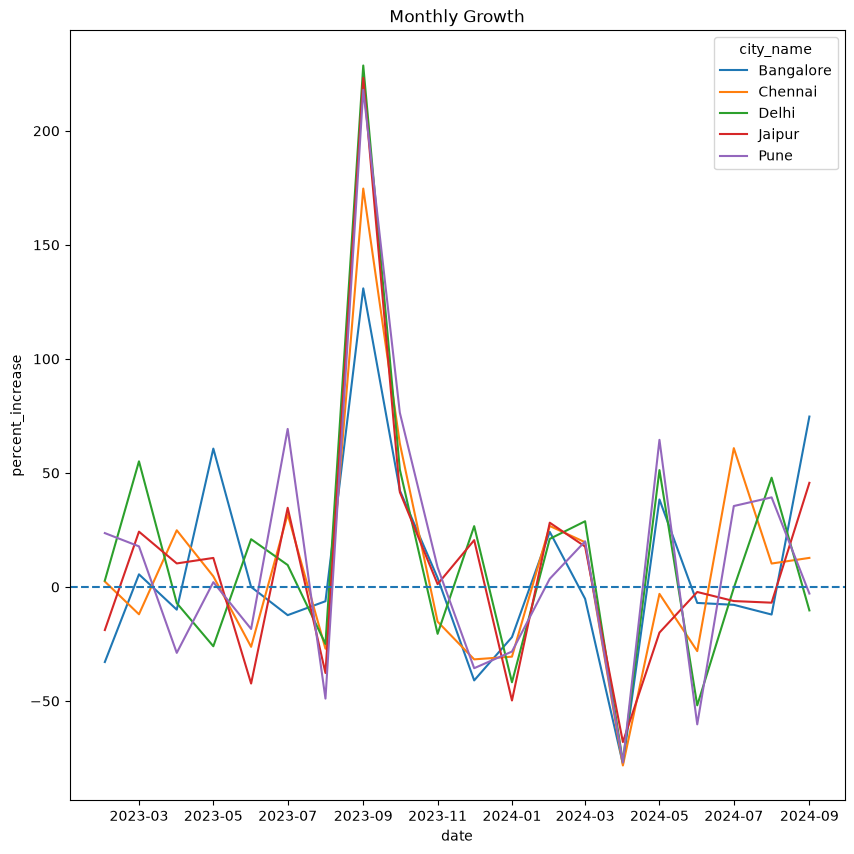

In [20]:
monthly_growth_top_cities = monthly_growth_top_cities[monthly_growth_top_cities['date'] < '2024-10-01']

plt.clf()
plt.figure(figsize=(10, 10))
sns.lineplot(data = monthly_growth_top_cities, x = 'date', y = 'percent_increase', hue = 'city_name')
plt.axhline(y = 0, linestyle='--')
plt.title("Monthly Growth")
plt.show()

The results indicate that all 5 cities experienced large month-to-month fluctuations throughout the covered time periods. The most significant increase in sales occurred during `2023-09`, when `Bangalore`, `Chennai`, `Delhi`, `Jaipur` and `Pune` recorded substantial revenue increases of `130.92%`, `174.69%`, `228.65%`, `223.21%` and `217.99%` respectively. This was followed by further growth in all 5 cities in `2023-10`. 

Following this trend of growth, sales performance became more varied towards the end of 2023 and into 2024. Although the percentage growth decreased across several months, it's important to note that a positive percentage is still an increase from the prior month. As an example, `Pune's` revenue increased from `88,400` in `2023-09` to `155,950` in `2023-10` and `169,350` in `2023-11`, despite the percentage growth falling from `217.99%` to `76.41%` and falling again to `8.59%`. 

There was a notable period of decline in `2024-04`, when all five cities experienced negative monthly growth of between `-68.00%` and `-78.28%`. The recovery following this decline varied in each city. `Pune` experienced a strong recovery between `May`, `July` and `August`, and `Chennai` had consecutive growth between `June` all the way up through `September`. `Bangalore` also had a `74.72%` increase in `2024-10`.

Overall, the sales analysis shows that sales performance is highly volatile rather than consistently increasing or decreasing. The five cities each experience periods of rapid growth, slow growth and decline throughout the time-series. `Pune` and `Chennai` show a relatively strong recovery towards the end of the data, providing additional evidence of demand that can be considered along with total revenue, market penetration and consumer activity. 

#### Quarterly Returns

The previous analysis examined the growth and decline of revenue on a month-to-month basis, highlighting periods of growth, decline and volatility across different cities in India. However, monthly sales changes are highly variable and can make it difficult to visualise the underlying trend in the overall sales data. 

To provide a more clear, less noisy view of sales performance, this analysis aggregates the monthly sales into quarterly periods, using `cr_month_sale` as the target variable as opposed to `percent_increase`, resulting in an analysis of raw revenue figures as opposed to a change in percentage. This reduces the effect of month to month fluctuations and allows the overall revenue trends of the five highest performing cities to be visualised. 

In [21]:
#### Create quarterly sales
# Create quarter column
monthly_growth_top_cities['quarter'] = monthly_growth_top_cities['date'].dt.to_period('Q')

# Calculate quarterly sales for each city and store it in a new dataframe
quarterly_returns = monthly_growth_top_cities.groupby(['city_name', 'quarter'])['cr_month_sale'].sum().reset_index()
print(quarterly_returns.head())

# Filter out Q1 2023 as it starts in Feb so is incomplete. Also filter out Q4 2024 as it is also incomplete.
quarterly_returns = quarterly_returns[
    (quarterly_returns['quarter'] >= '2023Q2') & (quarterly_returns['quarter'] <= '2024Q3')]
print(quarterly_returns['quarter'].unique())

# Convert quarter column to string so it can be plotted
quarterly_returns['quarter'] = quarterly_returns['quarter'].astype('str')

   city_name quarter  cr_month_sale
0  Bangalore  2023Q1          50870
1  Bangalore  2023Q2          99100
2  Bangalore  2023Q3         135870
3  Bangalore  2023Q4         270780
4  Bangalore  2024Q1         167000
<PeriodArray>
['2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3']
Length: 6, dtype: period[Q-DEC]


Text(0.5, 1.0, 'Quarterly Returns')

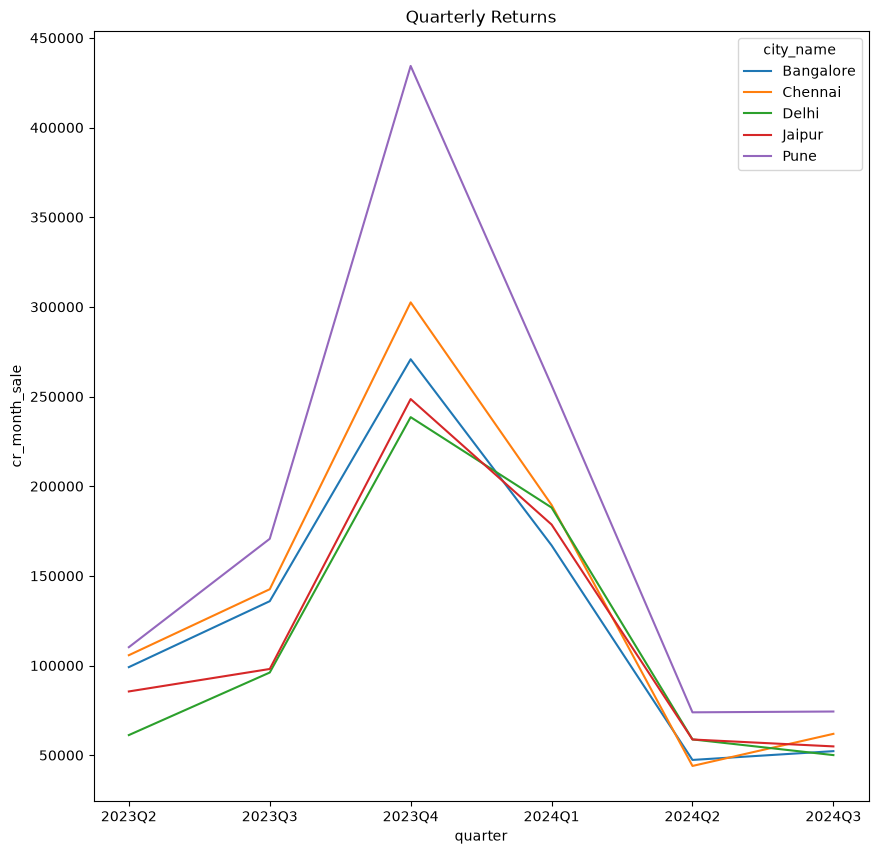

In [22]:

plt.figure(figsize=(10, 10))
sns.lineplot(data = quarterly_returns, x = 'quarter', y = 'cr_month_sale', hue = 'city_name')
plt.title("Quarterly Returns")

The quarterly sales trend provides more evidence as to which cities stand out for expansion. `Pune` stands out as the best-performing city, having consistently generated the highest level of revenue across every financial quarter in the dataset. Its revenue peaked at `434,330` in `2023Q4`, substantially higher than the other cities, and remained the highest in both `2024Q1` up to `2024Q3`. In the final quarter Pune also showed a slight recovery from its dip in sales, increasing from `73,900` to `74,350`. 

`Chennai` and `Bangalore` also portrayed a relatively strong market performance. Both cities consistently ranked in the highest performing markets across the dataset, with their sales peaking at `302,500` and `270,780` respectively in `2023Q4`. Following a decline in 2024, `Chennai` showed signs of recovery while `Bangalore` remained relatively stable.

`Jaipur` and `Delhi` also showed a fairly strong market performance, particularly in `2023Q4`. However, both cities are consistently the weakest two in sales performance out of the top 5 cities, with `Delhi's` quarterly revenue falling to `50,050` and `Jaipur's` to `54,900` in the `2024Q3`. 

Overall, the quarterly analysis strengthens `Pune` as being the strongest candidate for expansion, as it consistently generates the highest number of revenue at every quarter in the dataset. `Chennai` and `Bangalore` also show a high existing sales activity and should be considered alongside `Pune` as areas to expand to. With that said however, revenue alone should not be the sole indicator of a city being viable; market size, market penetration and rental costs should also be a factor in making the final decision. 

## <u>Which Cities Look Commercially Attractive Relative to Predicted Rent?</u>

The previous analyses have focussed primarily on revenue and customer activity, but those alone do not account for the cost of entering the market of each city. The estimated cost of rent can therefore provide an additional dimension when considering where to expand to.

To assess this, the following analysis will calculate the estimated cost of rent per customer for each city. While this is not a direct measure of profitability, it provides an indication of how rental costs relate to the existing customer base of each city.

``` sql
WITH city_table
AS
(SELECT
	ci.city_name,
	COUNT (DISTINCT s.customer_id) as total_customers,
	ROUND(
		SUM(s.total)::numeric/COUNT(DISTINCT s.customer_id), 2) as average_revenue
	
FROM sales as s
JOIN customers as c
ON s.customer_id = c.customer_id
JOIN city as ci
ON c.city_id = ci.city_id
GROUP BY 1),

city_rent 
AS
(SELECT  
	city_name, 
	estimated_rent
FROM city)

SELECT
	cr.city_name, 
	cr.estimated_rent,
	ct.total_customers,
	ct.average_revenue,
	ROUND (cr.estimated_rent::NUMERIC/ct.total_customers, 2) as avg_rent_per_cx
FROM city_rent as cr
JOIN city_table as ct
ON cr.city_name=ct.city_name
```

In [23]:
avg_rent_per_customer = pd.read_csv('SQL Queries/avg rent per customer.csv')
avg_rent_per_customer = avg_rent_per_customer.sort_values(by='avg_rent_per_cx', ascending=False)


,city_name,estimated_rent,total_customers,average_revenue,avg_rent_per_cx
5,Mumbai,31500,27,8703.70,1166.67
6,Hyderabad,22500,21,6262.86,1071.43
0,Bangalore,29700,39,22054.10,761.54
7,Ahmedabad,14400,23,5986.52,626.09
8,Kolkata,16200,28,6123.57,578.57
9,Surat,13500,27,6538.52,500.00
10,Lucknow,9000,21,5209.52,428.57
1,Chennai,17100,42,22479.05,407.14
4,Delhi,22500,68,11035.59,330.88
12,Nagpur,7200,24,5835.42,300.00


<Figure size 640x480 with 0 Axes>

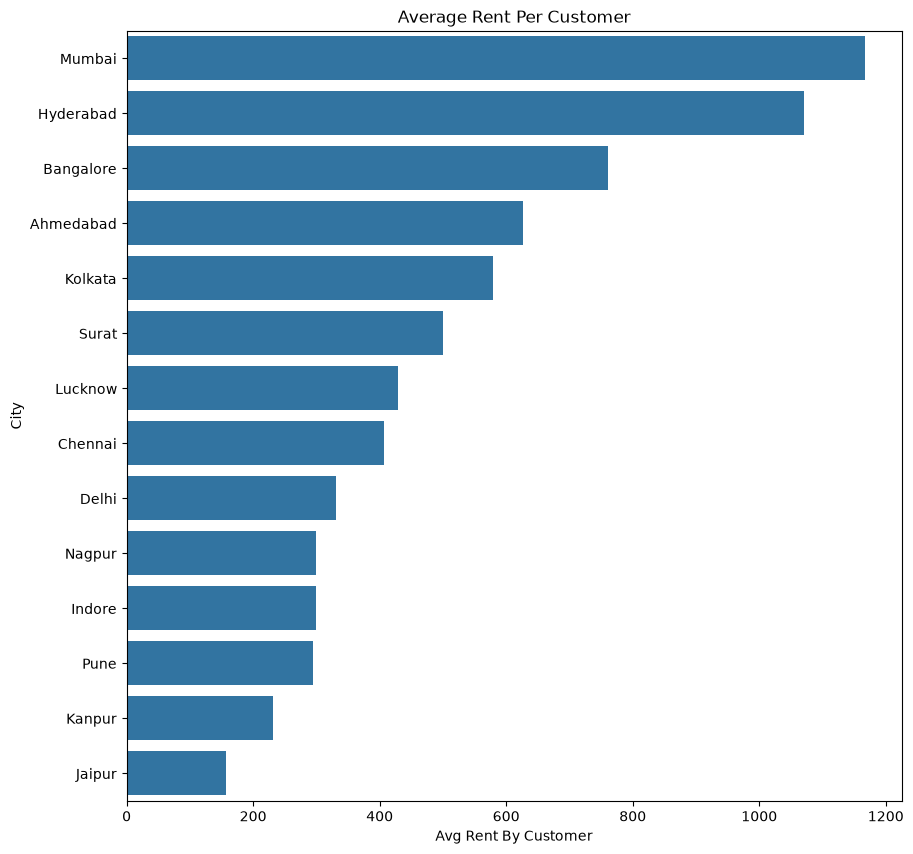

In [24]:
display(avg_rent_per_customer)
plt.clf()
plt.figure(figsize=(10, 10))
sns.barplot(data = avg_rent_per_customer, x = 'avg_rent_per_cx', y = 'city_name')
plt.title("Average Rent Per Customer")
plt.xlabel("Avg Rent By Customer")
plt.ylabel("City")
plt.show()

The results show that there is a large variation in the estimated rental costs per customer across the different cities in India. `Jaipur` has the lowest rent per customer at `156.52` followed by `Kanpur` at `231.43` and `Pune` at `294.23`. This implies that these cities have a relatively low estimated rental cost when compared against the size of their existing customer bases.

`Pune` stands out in particular as it combines a comparatively low estimated rental cost per customer with the largest overall revenue performance in the prior analyses. Its estimated rent is `294.23` and it also had the highest total revenue per customer and it was the best performing market in every quarter. This provides further evidence that `Pune` offers a strong balance between estimated customer demand and estimated operational costs. 

`Jaipur` is also a very strong city, given that it has the lowest estimated operational costs at `156.52` and the largest number of existing customers at `69`. However, it should be noticed that it has a smaller estimated market size and lower revenue per customer when compared with `Pune`, `Chennai` and `Bangalore`. 

At the other end of the spectrum, `Mumbai` and `Hyderabad` have the highest estimated rental costs per customer at `1166.67` and `1071.43` respectively. `Bangalore` also has a high rental cost at `761.54` despite it having some of the highest revenue per customer and strong consumer activity. This suggests that while these cities may have substantial demand, their higher estimated rental costs per customer could make them less attractive than lower cost alternatives, as the primary months of expansion could perhaps generate less revenue when accounting for rental costs. 

Overall, `Pune` and `Jaipur` jump out as being particularly attractive as they offer a combination of cheaper operational costs, a strong existing customer base and strong revenue. Cities such as `Bangalore` may require stronger future demand to justify their higher operational costs. 


## <u>Expansion Recommendation</u>

Based on the findings across the analyses, I recommend that Monday Coffee prioritises `Pune`, `Chennai` and `Jaipur` for its initial three storefronts.

<u>`Pune`</U> is by far the strongest option for expansion. It consistently performed strongly across almost every metric analysed. It had the highest revenue in `2024Q4` at `434330`, a relatively high market penetration at `0.0028%` and outperformed every other city in terms of revenue at every quarter. Additionally, it has the 3rd cheapest rent per customer out of all of the cities at `294.23`. It also achieved the highest average revenue per customer out of all of the cities at `24197.88`. Although its estimated coffee-drinking population is smaller than the likes of Dubai, Bangalore and Mumbai, the existing data on customer activity and revenue provides strong evidence for the demand of Monday Coffee in `Pune`. I therefore recommend `Pune` as being the strongest city to expand to.

<u>`Chennai`</u> is also a fairly strong city to expand to, given that it combines a relatively large potential market (`2.78 million`) with customer demand and relatively low operational costs. The city has an estimated `2.78 million` coffee drinkers and an existing customer base of `42`. It generated `302,500` in `2024Q3`, making it the second-best performing city in the dataset. It also had an average revenue per customer of `22479.05`, which was the second-ranked out of all of the cities. Furthermore, it has an estimated rent per customer of `407.14`, ranking it in the middle of the dataset when it comes to rental prices. Although this is higher than the likes of `Pune` or `Jaipur`, it is still substantially cheaper than some of the more expensive cities in the dataset and the city offers a relatively large potential market while already demonstrating comparatively strong revenue performance and customer activity. 

<u>`Jaipur`</u> is my final recommendation as to where to expand to. Although its estimated market side (`1 million`) is relatively smaller than `Pune` or `Chennai`, it is still the 4th best performing city for both revenue gained in `2024Q3` `(248580)` as well as average revenue per customer `(11644.20)`. It also has the largest existing customer base of an city analysed (`69`), which coupled with its relatively low estimated coffee-drinking population gives it a market penetration of `~0.007%`, the highest of all the cities. Furthermore, `Jaipur` also has the lowest estimated rent per customer in the dataset at `156.52`. Although `Jaipur` does not perform quite as well as `Bangalore` in terms of revenue, its combination of a large existing customer base, highest estimated market penetration and low rental costs makes it very attractive as a lower-cost expansion opportunity. 





